Spider ML Task 0 - Bonus Task(Simple Neural Network )

Importing Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

 Loading the Iris Dataset

In [8]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)
print(X[:5])
print(y[:5])

(150, 4)
(150,)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Splitting the Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Data Normalization

In [10]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(X_train[:5])

[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]


 One Hot Encoding

In [11]:
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

y_train_encoded = one_hot_encode(y_train, 3)
y_test_encoded = one_hot_encode(y_test, 3)

print(y_train_encoded[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


Initializing the Neural Network

In [13]:
input_size = 4
hidden1_size = 3
hidden2_size = 3
output_size = 3

W1 = np.random.randn(input_size, hidden1_size)
b1 = np.zeros((1, hidden1_size))

W2 = np.random.randn(hidden1_size, hidden2_size)
b2 = np.zeros((1, hidden2_size))

W3 = np.random.randn(hidden2_size, output_size)
b3 = np.zeros((1, output_size))

Activation Functions

In [14]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

Forward Propagation

In [15]:
def forward_propagation(X):

    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

 Loss Function

In [16]:
def compute_loss(y_true, y_pred):

    n = y_true.shape[0]

    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n

    return loss

 Backpropagation and Training

In [17]:
learning_rate = 0.01
epochs = 1000

losses = []

n = X_train.shape[0]

for epoch in range(epochs):

    Z1, A1, Z2, A2, Z3, A3 = forward_propagation(X_train)

    loss = compute_loss(y_train_encoded, A3)

    losses.append(loss)

    dZ3 = A3 - y_train_encoded

    dW3 = (1/n) * np.dot(A2.T, dZ3)
    db3 = (1/n) * np.sum(dZ3, axis=0, keepdims=True)

    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * (Z2 > 0)

    dW2 = (1/n) * np.dot(A1.T, dZ2)
    db2 = (1/n) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 > 0)

    dW1 = (1/n) * np.dot(X_train.T, dZ1)
    db1 = (1/n) * np.sum(dZ1, axis=0, keepdims=True)

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 1.1008602334315991
Epoch 100, Loss: 0.9456401295066438
Epoch 200, Loss: 0.8478042325222954
Epoch 300, Loss: 0.6901293341539921
Epoch 400, Loss: 0.5415105017504949
Epoch 500, Loss: 0.4901992382191063
Epoch 600, Loss: 0.46261032558168486
Epoch 700, Loss: 0.44352119863790473
Epoch 800, Loss: 0.4266155693787173
Epoch 900, Loss: 0.41010627244081743


Model Predictions and Accuracy

In [18]:
_, _, _, _, _, A3_test = forward_propagation(X_test)

predictions = np.argmax(A3_test, axis=1)

accuracy = np.mean(predictions == y_test)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


Loss Graph

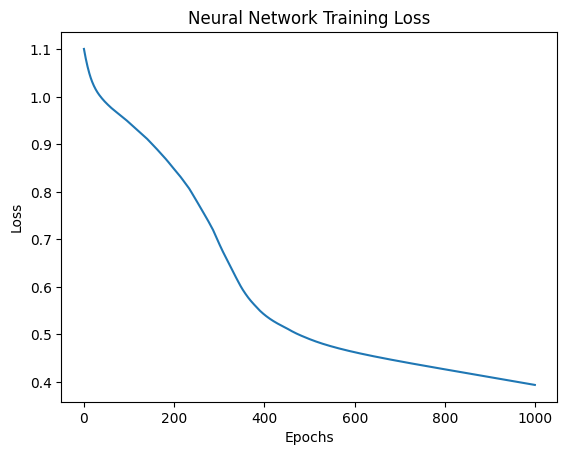

In [19]:
plt.plot(losses)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")

plt.show()